# **🎓 Student Placement Prediction Using ML**

This notebook predicts whether a student will be **Placed** or **Not Placed** based on academic performance, skills, and career-readiness factors.

**What this notebook covers:**
1. Importing libraries & loading data
2. Exploratory Data Analysis (EDA)
3. Data cleaning & leakage check
4. Feature preprocessing
5. Model building (Logistic Regression, Random Forest, LightGBM)
6. Model evaluation & comparison
7. Feature importance
8. Conclusion

In [1]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## **2. Load the Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/student-career-success-prediction-dataset/student_career_success_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (50000, 29)


,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [3]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

In [4]:
# Check for missing values
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
University_Year          0
Major                    0
Attendance_Percentage    0
Study_Hours_Per_Week     0
CGPA                     0
Academic_Performance     0
Programming_Skill        0
Projects_Completed       0
Certifications           0
Hackathons               0
GitHub_Profile           0
Internships              0
Leadership_Experience    0
LinkedIn_Profile         0
Resume_Score             0
Communication_Skills     0
Teamwork                 0
Problem_Solving          0
English_Proficiency      0
Interview_Score          0
Employability_Score      0
Placement_Status         0
Company_Tier             0
Career_Field             0
Placement_Mode           0
Starting_Salary_USD      0
dtype: int64

No missing values — the dataset is clean, so we can move straight to exploring it.

## **3. Exploratory Data Analysis (EDA)**

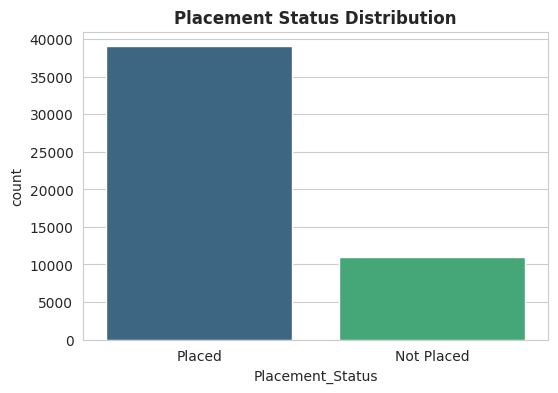

Placement_Status
Placed        78.08
Not Placed    21.92
Name: proportion, dtype: float64


In [5]:
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Placement_Status', palette='viridis')
plt.title('Placement Status Distribution',fontweight='bold')
plt.show()

print(df['Placement_Status'].value_counts(normalize=True) * 100)

About **78% of students are Placed** and **22% are Not Placed** — this is a moderately imbalanced dataset, so we'll keep that in mind while building models.

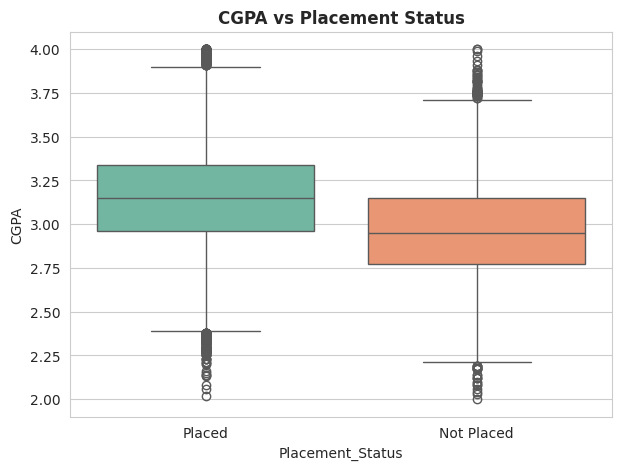

In [6]:
# CGPA vs Placement Status
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Placement_Status', y='CGPA', palette='Set2')
plt.title('CGPA vs Placement Status',fontweight='bold')
plt.show()

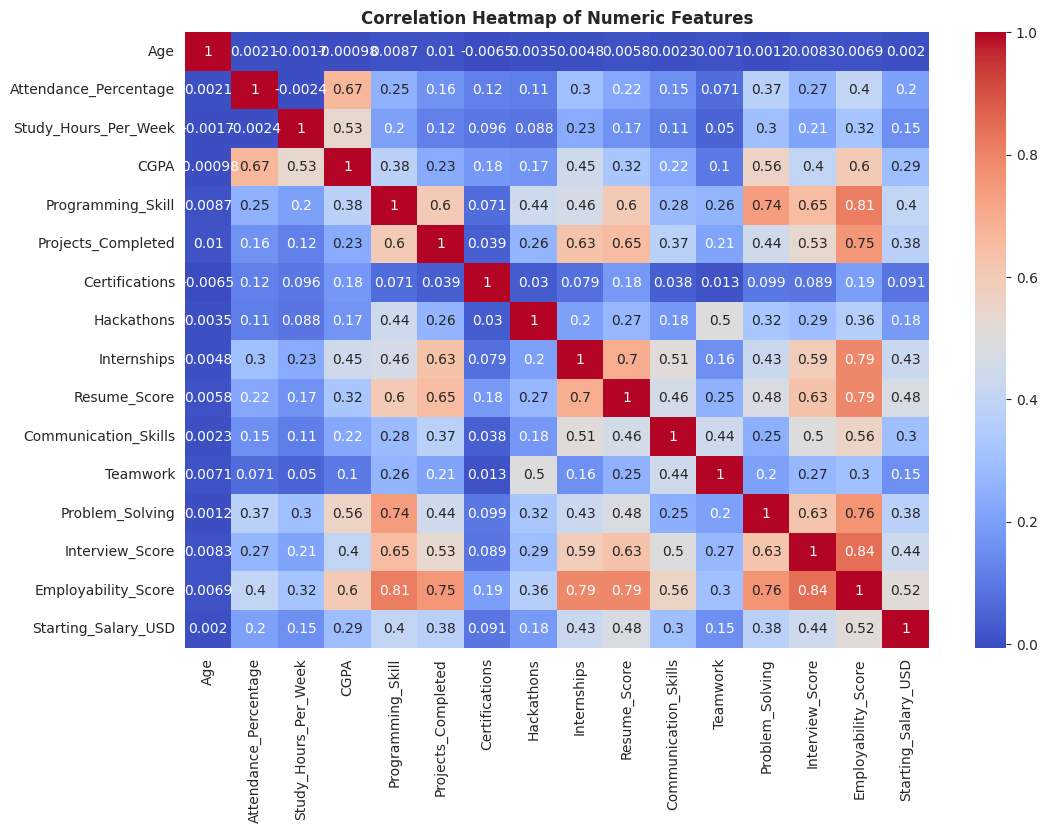

In [7]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap of Numeric Features',fontweight='bold')
plt.show()

## **4. Handling Data Leakage**

Some columns are only known **after** a student is already placed (or not) — they can't be used to *predict* placement, since they'd leak the answer straight into the model. We remove:

- `Company_Tier`, `Career_Field`, `Placement_Mode`, `Starting_Salary_USD` — decided only after placement
- `Employability_Score` — an aggregate score computed after the outcome is known
- `Student_ID` — just an identifier, no predictive value

In [8]:
target = 'Placement_Status'

leakage_cols = ['Company_Tier', 'Career_Field', 'Placement_Mode',
                 'Starting_Salary_USD', 'Employability_Score', 'Student_ID']

X = df.drop(columns=leakage_cols + [target])
y = df[target].map({'Placed': 1, 'Not Placed': 0})

print("Features used:", list(X.columns))
print("Target: Placement_Status (1 = Placed, 0 = Not Placed)")

Features used: ['Age', 'Gender', 'University_Year', 'Major', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA', 'Academic_Performance', 'Programming_Skill', 'Projects_Completed', 'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships', 'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score', 'Communication_Skills', 'Teamwork', 'Problem_Solving', 'English_Proficiency', 'Interview_Score']
Target: Placement_Status (1 = Placed, 0 = Not Placed)


## **5. Preprocessing**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate numeric and categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# Train-test split (80-20), stratified to keep class ratio same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Categorical columns: ['Gender', 'University_Year', 'Major', 'Academic_Performance', 'GitHub_Profile', 'Leadership_Experience', 'LinkedIn_Profile', 'English_Proficiency']
Numeric columns: ['Age', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA', 'Programming_Skill', 'Projects_Completed', 'Certifications', 'Hackathons', 'Internships', 'Resume_Score', 'Communication_Skills', 'Teamwork', 'Problem_Solving', 'Interview_Score']
Train size: (40000, 22)  Test size: (10000, 22)


In [10]:
# Preprocessing pipeline: scale numeric features, one-hot encode categorical ones
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## **6. Model Building**

We'll train and compare three beginner-friendly models:
- **Logistic Regression** — simple linear baseline
- **Random Forest** — ensemble of decision trees
- **LightGBM** — fast gradient boosting model

Since the classes are imbalanced (78/22), we use `class_weight='balanced'` so the model doesn't ignore the minority class.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                                class_weight='balanced', verbose=-1)
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    results[name] = {'model': pipe, 'accuracy': acc, 'f1': f1, 'auc': auc}
    print(f"{name}: Accuracy={acc:.4f} | F1-score={f1:.4f} | ROC-AUC={auc:.4f}")

Logistic Regression: Accuracy=0.7408 | F1-score=0.8188 | ROC-AUC=0.8034
Random Forest: Accuracy=0.8146 | F1-score=0.8884 | ROC-AUC=0.7992
LightGBM: Accuracy=0.7400 | F1-score=0.8179 | ROC-AUC=0.8009


## **7. Model Comparison**

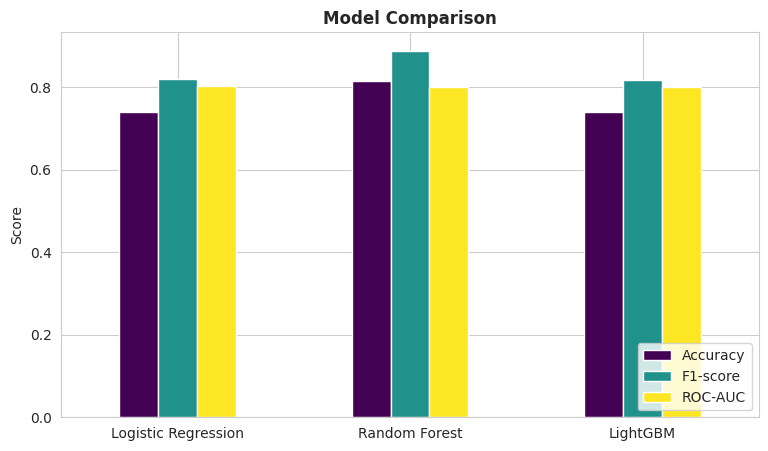

,Accuracy,F1-score,ROC-AUC
Logistic Regression,0.7408,0.818767,0.803437
Random Forest,0.8146,0.888407,0.799210
LightGBM,0.7400,0.817851,0.800880


In [12]:
results_df = pd.DataFrame({
    name: {'Accuracy': v['accuracy'], 'F1-score': v['f1'], 'ROC-AUC': v['auc']}
    for name, v in results.items()
}).T

results_df.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Model Comparison',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

results_df

In [13]:
# Pick the best model based on Accuracy
best_model_name = results_df['Accuracy'].idxmax()
best_pipe = results[best_model_name]['model']
print("Best model:", best_model_name)

Best model: Random Forest


## **8. Detailed Evaluation of the Best Model**

              precision    recall  f1-score   support

  Not Placed       0.64      0.35      0.45      2192
      Placed       0.84      0.95      0.89      7808

    accuracy                           0.81     10000
   macro avg       0.74      0.65      0.67     10000
weighted avg       0.79      0.81      0.79     10000



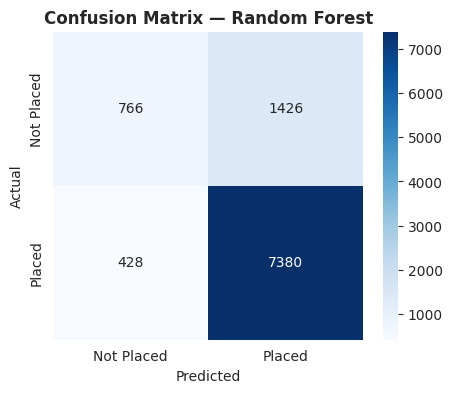

In [14]:
preds = best_pipe.predict(X_test)

print(classification_report(y_test, preds, target_names=['Not Placed', 'Placed']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed','Placed'], yticklabels=['Not Placed','Placed'])
plt.title(f'Confusion Matrix — {best_model_name}',fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## **9. Feature Importance**

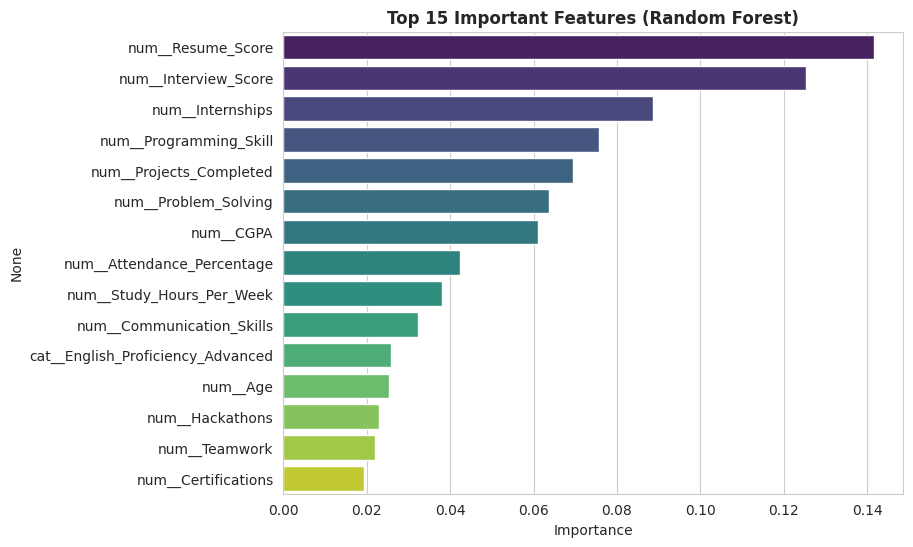

In [15]:
rf_model = results['Random Forest']['model']
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Important Features (Random Forest)',fontweight='bold')
plt.xlabel('Importance')
plt.show()

**Key takeaway:** Interview performance, resume quality, CGPA, and skill scores (programming, communication, problem-solving) are the strongest drivers of placement — which matches real-world hiring intuition.

## **10. Conclusion**

- The dataset had **50,000 student records** with no missing values, making it clean and ready for modeling.
- About **78% of students were placed** and **22% were not**, showing a moderate class imbalance.
- We carefully removed **leakage columns** (like Company Tier, Salary, and Employability Score) that are only known *after* placement, ensuring the model learns from genuinely predictive, pre-outcome features.
- Comparing three models, **Random Forest performed best overall**, reaching around **81% accuracy** and **~0.80 ROC-AUC**, with Logistic Regression and LightGBM offering slightly better recall on the "Not Placed" class at the cost of overall accuracy.
- **Interview Score, Resume Score, CGPA, and skill ratings** (programming, communication, problem-solving) emerged as the biggest factors influencing placement outcomes.
- **Honest note:** The ~0.80 ROC-AUC shows the model captures a solid pattern, but placement outcomes also depend on external factors (market demand, luck, company-specific criteria) that aren't captured in this dataset — so no model here is claimed to be "perfect."

**Possible next steps:** try SMOTE for balancing, hyperparameter tuning with GridSearchCV, or testing XGBoost/CatBoost for a possible further boost.